# 03 - Kiểm tra Pipeline Dataset - Jena Climate (Dự báo Thời tiết Seq2Seq)

Notebook này chứng minh rằng `src/data/dataset.py` (`WeatherForecastDataset`)
và `src/data/dataloader.py` biến đổi đúng các split đã xử lý, an toàn không rò rỉ
từ bước 02 thành các mẫu (168h lịch sử -> 72h dự báo) và các batch sẵn sàng
cho mô hình. Nó chỉ **gọi** pipeline và kiểm tra đầu ra của nó - logic
sliding-window nằm trong các module, không phải ở đây.
Không có mô hình nào được huấn luyện trong notebook này.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import json

import pandas as pd
import torch

import src.data.preprocessing as pp
from src.data.dataloader import build_dataloaders
from src.data.dataset import WeatherForecastDataset, validate_weather_batch

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "preprocessing"
print("Project root:", PROJECT_ROOT)
print("Processed dir exists:", PROCESSED_DIR.exists())

Project root: E:\Project_Deep\Project_DL_Weather_Forecasting
Processed dir exists: True


## 1. Nạp bộ dữ liệu đã xử lý

Đọc ba split an toàn không rò rỉ được tạo ra bởi bước 02
(`src/data/preprocessing.py`): đã được làm sạch, resample theo giờ,
tạo đặc trưng, chia tách theo thời gian, impute, và chuẩn hóa.

In [2]:
train_df = pd.read_csv(PROCESSED_DIR / "train_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
val_df = pd.read_csv(PROCESSED_DIR / "val_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])
test_df = pd.read_csv(PROCESSED_DIR / "test_processed.csv", parse_dates=[pp.TIMESTAMP_COLUMN])

print(f"train_processed.csv: {train_df.shape}")
print(f"val_processed.csv:   {val_df.shape}")
print(f"test_processed.csv:  {test_df.shape}")
train_df.head(3)

train_processed.csv: (49090, 33)
val_processed.csv:   (10519, 33)
test_processed.csv:  (10520, 33)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),...,missing_rh_pct,missing_VPmax_mbar,missing_VPact_mbar,missing_VPdef_mbar,missing_sh_gkg,missing_H2OC_mmolmol,missing_rho_gm3,missing_wv_ms,missing_max_wv_ms,missing_wd_deg
0,2009-01-01 00:00:00,0.948907,-2.014297,-2.074466,-1.968587,1.083659,-1.314739,-1.497932,-0.790657,-1.499869,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2009-01-01 01:00:00,0.948545,-1.986651,-2.046505,-1.931547,1.092974,-1.306490,-1.482811,-0.790727,-1.484279,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2009-01-01 02:00:00,0.975079,-2.067430,-2.128743,-2.038843,1.068674,-1.329717,-1.525958,-0.790727,-1.527308,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Nạp feature_schema.json

`feature_schema.json` là hợp đồng (contract) đã khóa từ bước 02: nó cố định
danh sách đặc trưng theo thứ tự, cột mục tiêu, và kích thước window/horizon để
chúng không bao giờ bị viết cứng ở đây hay trong code mô hình dùng chung.

In [3]:
with open(ARTIFACTS_DIR / "feature_schema.json", encoding="utf-8") as f:
    schema = json.load(f)

FEATURES = schema["ordered_features"]
TARGET = schema["target"]["name"]
INPUT_WINDOW = schema["window_contract"]["input_len_hours"]
HORIZON = schema["window_contract"]["horizon_hours"]

print(f"n_features = {len(FEATURES)}")
print(f"target = {TARGET!r} (schema index {schema['target']['index']})")
print(f"input_window = {INPUT_WINDOW} hours, horizon = {HORIZON} hours")

assert FEATURES == pp.FEATURE_COLUMNS, "notebook schema drifted from src.data.preprocessing.FEATURE_COLUMNS"
assert TARGET == pp.TARGET_COLUMN
print("OK: schema matches the preprocessing module's contract constants.")

n_features = 32
target = 'T (degC)' (schema index 1)
input_window = 168 hours, horizon = 72 hours
OK: schema matches the preprocessing module's contract constants.


## 3. Tạo Dataset

Mỗi split có một `WeatherForecastDataset` riêng - không bao giờ nối (concatenate) các split lại với nhau.

In [4]:
train_dataset = WeatherForecastDataset(train_df, FEATURES, TARGET, input_window=INPUT_WINDOW, horizon=HORIZON)
val_dataset = WeatherForecastDataset(val_df, FEATURES, TARGET, input_window=INPUT_WINDOW, horizon=HORIZON)
test_dataset = WeatherForecastDataset(test_df, FEATURES, TARGET, input_window=INPUT_WINDOW, horizon=HORIZON)

print("WeatherForecastDataset(\n"
      f"  df=train_df, features=<{len(FEATURES)} cols>, target={TARGET!r},\n"
      f"  input_window={INPUT_WINDOW}, horizon={HORIZON}\n)")

WeatherForecastDataset(
  df=train_df, features=<32 cols>, target='T (degC)',
  input_window=168, horizon=72
)


## 4. Độ dài Dataset và Shape của mẫu

Độ dài là số lượng sliding window *hợp lệ*: số hàng thô trừ đi
`input_window + horizon - 1`, trừ tiếp bất kỳ cửa sổ nào chạm vào một khoảng trống nơi
`T (degC)` (hay bất kỳ đặc trưng nào) bị để thiếu bởi bước tiền xử lý.

In [5]:
raw_windows = {
    "train": len(train_df) - (INPUT_WINDOW + HORIZON) + 1,
    "validation": len(val_df) - (INPUT_WINDOW + HORIZON) + 1,
    "test": len(test_df) - (INPUT_WINDOW + HORIZON) + 1,
}
kept_windows = {
    "train": len(train_dataset),
    "validation": len(val_dataset),
    "test": len(test_dataset),
}
summary = pd.DataFrame({"raw_candidate_windows": raw_windows, "kept_windows": kept_windows})
summary["dropped_for_missing_data"] = summary["raw_candidate_windows"] - summary["kept_windows"]
summary

,raw_candidate_windows,kept_windows,dropped_for_missing_data
train,48851,48851,0
validation,10280,10026,254
test,10281,9969,312


In [6]:
sample = train_dataset[0]
print("x:", sample["x"].shape, sample["x"].dtype)
print("y:", sample["y"].shape, sample["y"].dtype)
print("input_timestamps:", sample["input_timestamps"].shape, sample["input_timestamps"].dtype)
print("target_timestamps:", sample["target_timestamps"].shape, sample["target_timestamps"].dtype)

assert sample["x"].shape == (INPUT_WINDOW, len(FEATURES))
assert sample["y"].shape == (HORIZON, 1)
assert torch.isfinite(sample["x"]).all() and torch.isfinite(sample["y"]).all()
print("\nOK: sample shapes match [168, n_features] / [72, 1] and contain no NaN/Inf.")

x: torch.Size([168, 32]) torch.float32
y: torch.Size([72, 1]) torch.float32
input_timestamps: torch.Size([168]) torch.int64
target_timestamps: torch.Size([72]) torch.int64

OK: sample shapes match [168, n_features] / [72, 1] and contain no NaN/Inf.


## 5. Kiểm tra Dòng thời gian

Xác nhận giai đoạn dự báo bắt đầu đúng một giờ sau khi giai đoạn đầu vào
kết thúc - không có khoảng trống, không chồng lấn - cho một mẫu từ mỗi split.

In [7]:
def describe_window(dataset: WeatherForecastDataset, name: str, index: int = 0) -> None:
    bounds = dataset.window_bounds(index)
    gap_hours = (bounds["forecast_start"] - bounds["input_end"]).total_seconds() / 3600
    print(f"[{name}] sample {index}")
    print(f"  input period:    {bounds['input_start']}  ->  {bounds['input_end']}")
    print(f"  forecast period: {bounds['forecast_start']}  ->  {bounds['forecast_end']}")
    print(f"  gap between input end and forecast start: {gap_hours:.0f}h (expect 1h)\n")
    assert gap_hours == 1.0, "forecast must start immediately after input ends"


describe_window(train_dataset, "train")
describe_window(val_dataset, "validation")
describe_window(test_dataset, "test")
print("OK: forecast starts exactly 1 hour after input ends in every split.")

[train] sample 0
  input period:    2009-01-01 00:00:00  ->  2009-01-07 23:00:00
  forecast period: 2009-01-08 00:00:00  ->  2009-01-10 23:00:00
  gap between input end and forecast start: 1h (expect 1h)

[validation] sample 0
  input period:    2014-08-08 10:00:00  ->  2014-08-15 09:00:00
  forecast period: 2014-08-15 10:00:00  ->  2014-08-18 09:00:00
  gap between input end and forecast start: 1h (expect 1h)

[test] sample 0
  input period:    2015-10-20 17:00:00  ->  2015-10-27 16:00:00
  forecast period: 2015-10-27 17:00:00  ->  2015-10-30 16:00:00
  gap between input end and forecast start: 1h (expect 1h)

OK: forecast starts exactly 1 hour after input ends in every split.


In [8]:
with open(ARTIFACTS_DIR / "split_metadata.json", encoding="utf-8") as f:
    split_metadata = json.load(f)

train_end = pd.Timestamp(split_metadata["train"]["end"])
val_start = pd.Timestamp(split_metadata["validation"]["start"])

last_train_bounds = train_dataset.window_bounds(len(train_dataset) - 1)
first_val_bounds = val_dataset.window_bounds(0)

print(f"Last train sample's forecast ends:   {last_train_bounds['forecast_end']}  (train split ends {train_end})")
print(f"First val sample's input starts:     {first_val_bounds['input_start']}  (validation split starts {val_start})")

assert last_train_bounds["forecast_end"] <= train_end
assert first_val_bounds["input_start"] >= val_start
print("\nOK: no train sample's window reaches into validation, and no validation sample reaches back into train.")

Last train sample's forecast ends:   2014-08-08 09:00:00  (train split ends 2014-08-08 09:00:00)
First val sample's input starts:     2014-08-08 10:00:00  (validation split starts 2014-08-08 10:00:00)

OK: no train sample's window reaches into validation, and no validation sample reaches back into train.


## 6. Kiểm tra Batch

Bọc mỗi split trong một DataLoader và xác nhận chiều batch được thêm vào đúng cách.

In [9]:
BATCH_SIZE = 32
loaders = build_dataloaders(train_dataset, val_dataset, test_dataset, batch_size=BATCH_SIZE)

train_batch = next(iter(loaders["train"]))
print("X batch:", train_batch["x"].shape, " (expect [B, 168, n_features])")
print("y batch:", train_batch["y"].shape, " (expect [B, 72, 1])")
print("input_timestamps batch:", train_batch["input_timestamps"].shape)
print("target_timestamps batch:", train_batch["target_timestamps"].shape)

assert train_batch["x"].shape == (BATCH_SIZE, INPUT_WINDOW, len(FEATURES))
assert train_batch["y"].shape == (BATCH_SIZE, HORIZON, 1)

# Validate against TV1's locked WeatherBatch contract - the same check model code relies on.
validate_weather_batch(train_batch, n_features=len(FEATURES))
print("\nOK: batch shapes match [B,168,n_features] / [B,72,1] and pass validate_weather_batch.")

X batch: torch.Size([32, 168, 32])  (expect [B, 168, n_features])
y batch: torch.Size([32, 72, 1])  (expect [B, 72, 1])
input_timestamps batch: torch.Size([32, 168])
target_timestamps batch: torch.Size([32, 72])

OK: batch shapes match [B,168,n_features] / [B,72,1] and pass validate_weather_batch.


In [10]:
val_batch = next(iter(loaders["val"]))
test_batch = next(iter(loaders["test"]))
validate_weather_batch(val_batch, n_features=len(FEATURES))
validate_weather_batch(test_batch, n_features=len(FEATURES))
print("OK: validation and test batches also pass the contract validator.")

OK: validation and test batches also pass the contract validator.


## 4b. Nguyên nhân loại bỏ cửa sổ (Reject Reason)

§4 đã cho thấy bao nhiêu cửa sổ ứng viên bị loại, nhưng chưa cho biết *vì sao*.
Ô dưới đây tái hiện độc lập đúng công thức véc-tơ hóa mà
`WeatherForecastDataset._find_valid_starts` dùng (tổng tiền tố trên cờ "NaN/Inf" của
từng hàng), rồi tách riêng mỗi cửa sổ bị loại thành một trong bốn nhóm: hợp lệ,
chỉ do input (168h) có NaN/Inf, chỉ do target (72h) có NaN/Inf, hoặc cả hai — không
thay đổi logic loại bỏ thực tế trong `src/data/dataset.py`, chỉ phân rã nó để
kiểm tra.

In [11]:
import numpy as np


def window_rejection_breakdown(
    df: pd.DataFrame, features: list[str], target: str, input_window: int, horizon: int
) -> pd.Series:
    """Independent re-derivation of _find_valid_starts, split out by reject reason."""
    feature_arr = df[features].to_numpy(dtype=float)
    target_arr = df[target].to_numpy(dtype=float)
    n = len(feature_arr)
    window_len = input_window + horizon
    if n < window_len:
        return pd.Series(
            {
                "candidate_windows": 0,
                "valid_windows": 0,
                "rejected_input_only": 0,
                "rejected_target_only": 0,
                "rejected_both": 0,
            }
        )

    row_x_bad = ~np.isfinite(feature_arr).all(axis=1)
    row_y_bad = ~np.isfinite(target_arr)
    prefix_x = np.concatenate([[0], np.cumsum(row_x_bad.astype(np.int64))])
    prefix_y = np.concatenate([[0], np.cumsum(row_y_bad.astype(np.int64))])

    starts = np.arange(0, n - window_len + 1)
    x_bad = (prefix_x[starts + input_window] - prefix_x[starts]) > 0
    y_bad = (prefix_y[starts + window_len] - prefix_y[starts + input_window]) > 0

    return pd.Series(
        {
            "candidate_windows": len(starts),
            "valid_windows": int((~x_bad & ~y_bad).sum()),
            "rejected_input_only": int((x_bad & ~y_bad).sum()),
            "rejected_target_only": int((~x_bad & y_bad).sum()),
            "rejected_both": int((x_bad & y_bad).sum()),
        }
    )


reject_breakdown = pd.DataFrame(
    {
        "train": window_rejection_breakdown(train_df, FEATURES, TARGET, INPUT_WINDOW, HORIZON),
        "validation": window_rejection_breakdown(val_df, FEATURES, TARGET, INPUT_WINDOW, HORIZON),
        "test": window_rejection_breakdown(test_df, FEATURES, TARGET, INPUT_WINDOW, HORIZON),
    }
).T
display(reject_breakdown)

assert reject_breakdown.loc["train", "valid_windows"] == len(train_dataset)
assert reject_breakdown.loc["validation", "valid_windows"] == len(val_dataset)
assert reject_breakdown.loc["test", "valid_windows"] == len(test_dataset)
print("OK: valid_windows per split matches len(dataset) exactly - the breakdown above is a")
print("faithful decomposition of _find_valid_starts, not a separate/looser rule.")

,candidate_windows,valid_windows,rejected_input_only,rejected_target_only,rejected_both
train,48851,48851,0,0,0
validation,10280,10026,168,72,14
test,10281,9969,168,72,72


OK: valid_windows per split matches len(dataset) exactly - the breakdown above is a
faithful decomposition of _find_valid_starts, not a separate/looser rule.


**Phát hiện.** Xem bảng trên: `train` không có cửa sổ nào bị loại (không có long/critical
gap trong phạm vi train, theo Notebook 01 §4), trong khi `validation`/`test` có cửa sổ bị
loại vì chạm vào khoảng trống dài còn sót lại sau bước impute (Notebook 02 §5/§7b).
Số liệu `valid_windows` ở đây khớp chính xác với `len(dataset)` ở §4, chứng minh bảng
phân rã nguyên nhân này không phải một quy tắc loại bỏ khác — chỉ là cùng một quy tắc
được tách ra để quan sát.

**Ảnh hưởng.** Nếu số cửa sổ bị loại vì `rejected_target_only`/`rejected_both` cao bất
thường ở một split, đó là dấu hiệu split đó chứa nhiều khoảng trống dài trùng đúng
vùng dùng để tính forecast — ảnh hưởng trực tiếp đến số mẫu dùng để đánh giá mô
hình (validation/test ít mẫu hơn dự kiến thuần túy từ số hàng).

**Quyết định.** Không thay đổi gì ở đây — phân rã này thuần túy phục vụ chuẩn
đoán; quy tắc loại bỏ thực tế vẫn do `WeatherForecastDataset._find_valid_starts` quyết
định như đã chứng minh ở trên.

## 7. Trực quan hóa mẫu (Sample Visualization)

Chọn một mẫu cụ thể từ `train_dataset` và vẽ chuỗi 168h đầu vào cùng 72h dự báo
ở đơn vị gốc (độ C, %), bằng cách áp dụng ngược `scaler.mean_`/`scaler.scale_` cho
từng cột (chỉ để vẽ biểu đồ ở đây — không dùng cho huấn luyện hay đánh giá),
cùng với đặc trưng thời gian dạng chu kỳ `hour_sin`.

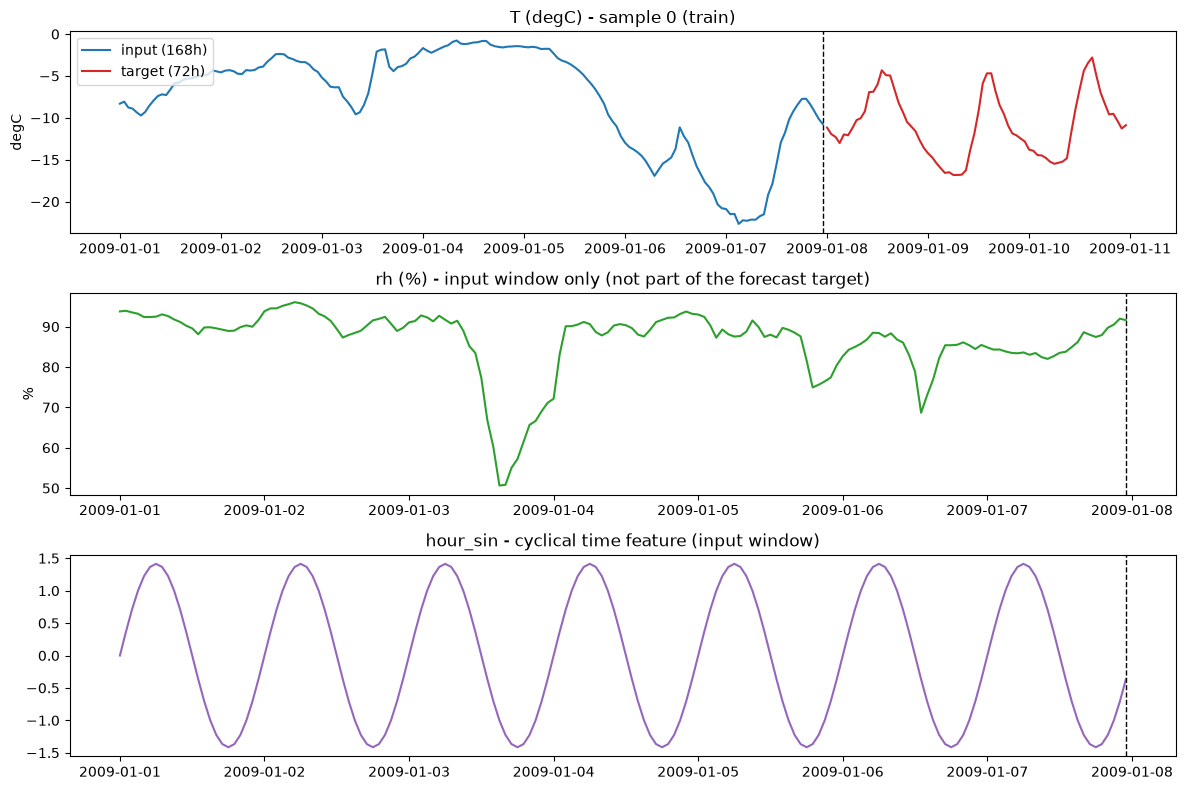

Input:  2009-01-01 00:00:00 -> 2009-01-07 23:00:00
Target: 2009-01-08 00:00:00 -> 2009-01-10 23:00:00


In [12]:
import joblib
import matplotlib.pyplot as plt

sample_index = 0
sample = train_dataset[sample_index]
bounds = train_dataset.window_bounds(sample_index)
scaler = joblib.load(ARTIFACTS_DIR / "scaler.joblib")


def inverse_feature(scaled_values: np.ndarray, feature_name: str) -> np.ndarray:
    idx = FEATURES.index(feature_name)
    return scaled_values * scaler.scale_[idx] + scaler.mean_[idx]


input_ts = pd.to_datetime(sample["input_timestamps"].numpy(), unit="s")
target_ts = pd.to_datetime(sample["target_timestamps"].numpy(), unit="s")

input_temp = inverse_feature(sample["x"][:, FEATURES.index(TARGET)].numpy(), TARGET)
target_temp = inverse_feature(sample["y"][:, 0].numpy(), TARGET)
input_humidity = inverse_feature(sample["x"][:, FEATURES.index("rh (%)")].numpy(), "rh (%)")
input_hour_sin = sample["x"][:, FEATURES.index("hour_sin")].numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

axes[0].plot(input_ts, input_temp, color="tab:blue", label="input (168h)")
axes[0].plot(target_ts, target_temp, color="tab:red", label="target (72h)")
axes[0].axvline(bounds["input_end"], color="black", linestyle="--", linewidth=1)
axes[0].set_title(f"T (degC) - sample {sample_index} (train)")
axes[0].set_ylabel("degC")
axes[0].legend(loc="upper left")

axes[1].plot(input_ts, input_humidity, color="tab:green")
axes[1].axvline(bounds["input_end"], color="black", linestyle="--", linewidth=1)
axes[1].set_title("rh (%) - input window only (not part of the forecast target)")
axes[1].set_ylabel("%")

axes[2].plot(input_ts, input_hour_sin, color="tab:purple")
axes[2].axvline(bounds["input_end"], color="black", linestyle="--", linewidth=1)
axes[2].set_title("hour_sin - cyclical time feature (input window)")

fig.tight_layout()
plt.show()

print(f"Input:  {bounds['input_start']} -> {bounds['input_end']}")
print(f"Target: {bounds['forecast_start']} -> {bounds['forecast_end']}")

**Phát hiện.** Biểu đồ trên cho thấy trực quan đúng những gì §5 đã xác nhận
bằng số: 168 giờ đầu vào (`x`, màu xanh) kết thúc đúng tại đường kẻ đứt, và 72
giờ dự báo (`y`, màu đỏ) bắt đầu ngay sau đó — không chồng, không hở; `hour_sin`
lặp lại mỗi 24 giờ đúng như thiết kế ở Notebook 01 §5.

**Ảnh hưởng.** Đây là bằng chứng trực quan cuối cùng rằng một `WeatherSample` thực sự
chứa dữ liệu liên tục, đúng đơn vị vật lý sau khi được giải chuẩn hóa — hữu ích
để phát hiện lỗi trực quan (vd. lệch trục thời gian, sai thứ tự cột) mà các assert
số học ở §5/§6 có thể không bắt được.

**Quyết định.** Không thay đổi pipeline — ô này chỉ phục vụ kiểm tra trực quan thủ
công, bổ sung cho các assert tự động ở §4/§5/§6.

## Tóm tắt

- `WeatherForecastDataset` xây dựng các sliding window 168h vào / 72h ra
  một cách độc lập cho từng split, loại bỏ bất kỳ cửa sổ nào chạm vào một giá trị
  thiếu - không bao giờ bịa đặt dữ liệu huấn luyện.
- Các cửa sổ không bao giờ vắt qua ranh giới split vì mỗi dataset chỉ được
  xây dựng từ các hàng của đúng split đó.
- Các batch do `src/data/dataloader.py` tạo ra khớp với hợp đồng `WeatherBatch`
  (`x [B,168,F]`, `y [B,72,1]`, timestamp được căn chỉnh) mà
  `src/data/dataset.py::validate_weather_batch` áp đặt cho mọi mô hình
  (Seq2Seq LSTM, Attention LSTM, Transformer).
- Nguyên nhân loại bỏ cửa sổ được phân ra thành input-only / target-only / cả hai, và số
  mẫu hợp lệ khớp chính xác với `len(dataset)`; một mẫu cụ thể được vẽ trực quan
  (temperature, humidity, time feature) để đối chiếu với các assert số học ở trên.
- Pipeline dataset đã sẵn sàng để bàn giao cho nhóm Huấn luyện Mô hình.